#Breve análise exploratória dos dados

É nessa etapa que entendemos como os dados se comportam, se têm algum padrão, como estão distribuídos, etc. para entender qual/quais modelos usar. É uma das etapas mais cruciais, pois garante maior intimidade com os dados.

## Visualizando valores e exibindo algumas medidas dos dados

In [2]:
import pandas as pd

In [3]:
# conseguimos puxar os dados por URL pegando o link raw do github
url = "https://raw.githubusercontent.com/cassiasamp/build_with_ai_ws/refs/heads/main/dados/dados_tratados.csv"

In [4]:
df = pd.read_csv(url)

In [5]:
# exibindo as primeiras cinco linhas para ter uma noção dos dados
df.head(n=5)

,idade,sistolica,diastolica,glicose,temperatura,batimentos,risco
0,25,130,80,15.0,98.0,86,alto
1,35,140,90,13.0,98.0,70,alto
2,29,90,70,8.0,100.0,80,alto
3,30,140,85,7.0,98.0,70,alto
4,35,120,60,6.1,98.0,76,baixo


In [6]:
# exibindo informação dos dados para ver quantidade, tipo de dado e valores faltantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   idade        1014 non-null   int64  
 1   sistolica    1014 non-null   int64  
 2   diastolica   1014 non-null   int64  
 3   glicose      1014 non-null   float64
 4   temperatura  1014 non-null   float64
 5   batimentos   1014 non-null   int64  
 6   risco        1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [7]:
# mostrando as medidas de estatística descritiva (dos dados numéricos)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
idade,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
sistolica,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
diastolica,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
glicose,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
temperatura,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
batimentos,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


In [8]:
# vendo como estão as classes do risco, se tem números parecidos ou se tem mais de algum tipo do que de outro
df['risco'].value_counts()

,count
risco,
baixo,406
medio,336
alto,272


In [9]:
# vendo como estão as idades
df['idade'].value_counts()

,count
idade,
23,71
19,67
17,63
15,60
35,50
25,48
32,48
22,45
50,43


## Gerando alguns gráficos

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

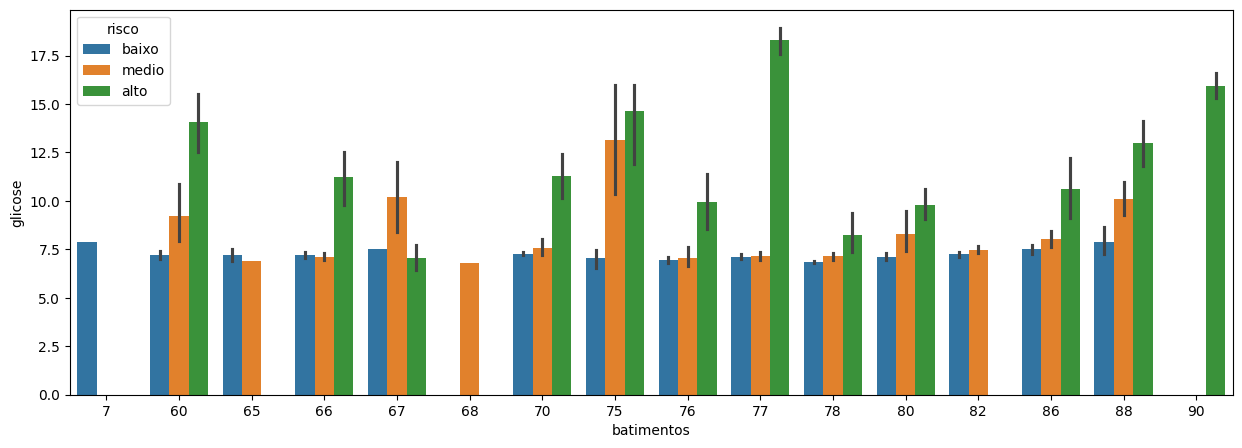

In [13]:
# o quanto o risco tem a ver com batimentos e glicose, será que têm relação?
plt.figure(figsize=(15, 5))
sns.barplot(x='batimentos', y='glicose', data=df, hue='risco');

Podemos perceber que não há um padrão claro, mas para alguns valores de batimentos, a glicose também fica alta.

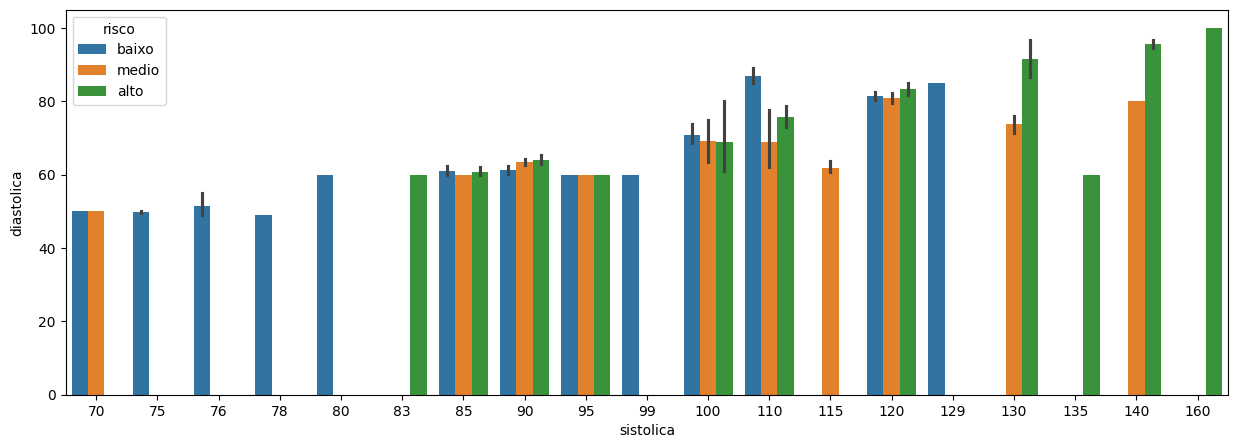

In [14]:
# qual a relação entre sistolica, diastolica e risco?
plt.figure(figsize=(15, 5))
sns.barplot(x='sistolica', y='diastolica', data=df, hue='risco');

Neste gráfico, podemos ver que o risco aumenta quando ambas as pressões sobem.

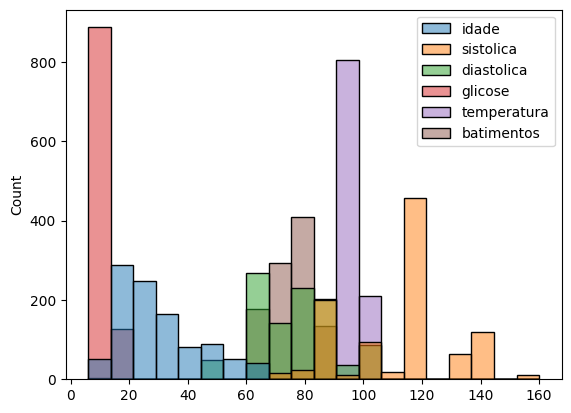

In [15]:
# como está a distribuição destes dados?
sns.histplot(data=df);

Percebemos que os nossos dados estão longe de serem normais (no sentindo de serem próximos de uma curva normal).

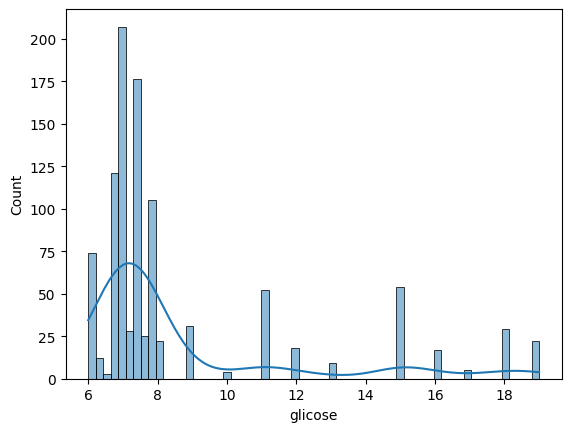

In [16]:
sns.histplot(data=df, x='glicose', kde=True);

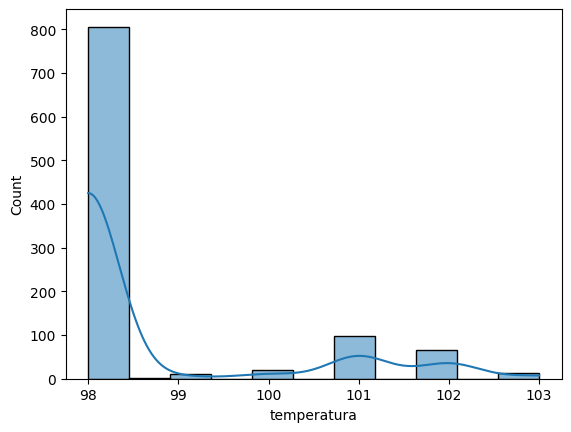

In [17]:
sns.histplot(data=df, x='temperatura', kde=True);

Teríamos que ver para cada dado, mas pelo menos para glicose e temperatura, temos distribuições assimétricas e enviesadas à direita, consideradas log normais. O que indica que poderíamos usar log para torna-las mais próximas de uma curva normal.

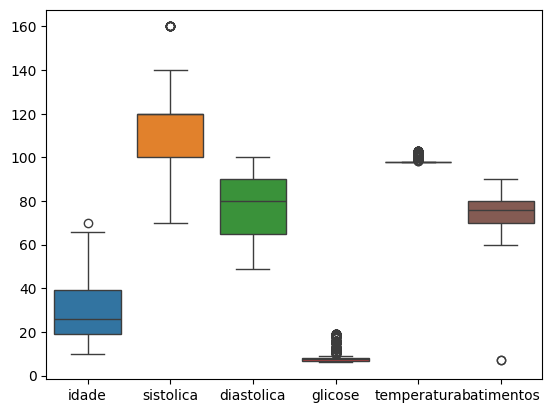

In [18]:
# com boxplots podemos ver se tem dados com valores muito acima ou abaixo da média - dados fora da curva, ou outliers
sns.boxplot(data=df);

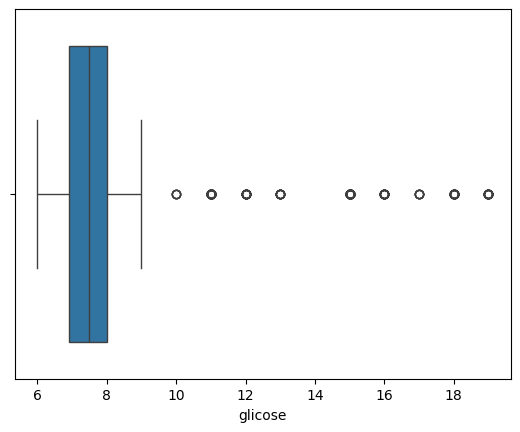

In [19]:
sns.boxplot(data=df['glicose'], orient='h');

Temos uma quantidade alta de outliers na glicose e temperatura parece que temos também. Teríamos que investigar um pouco mais.

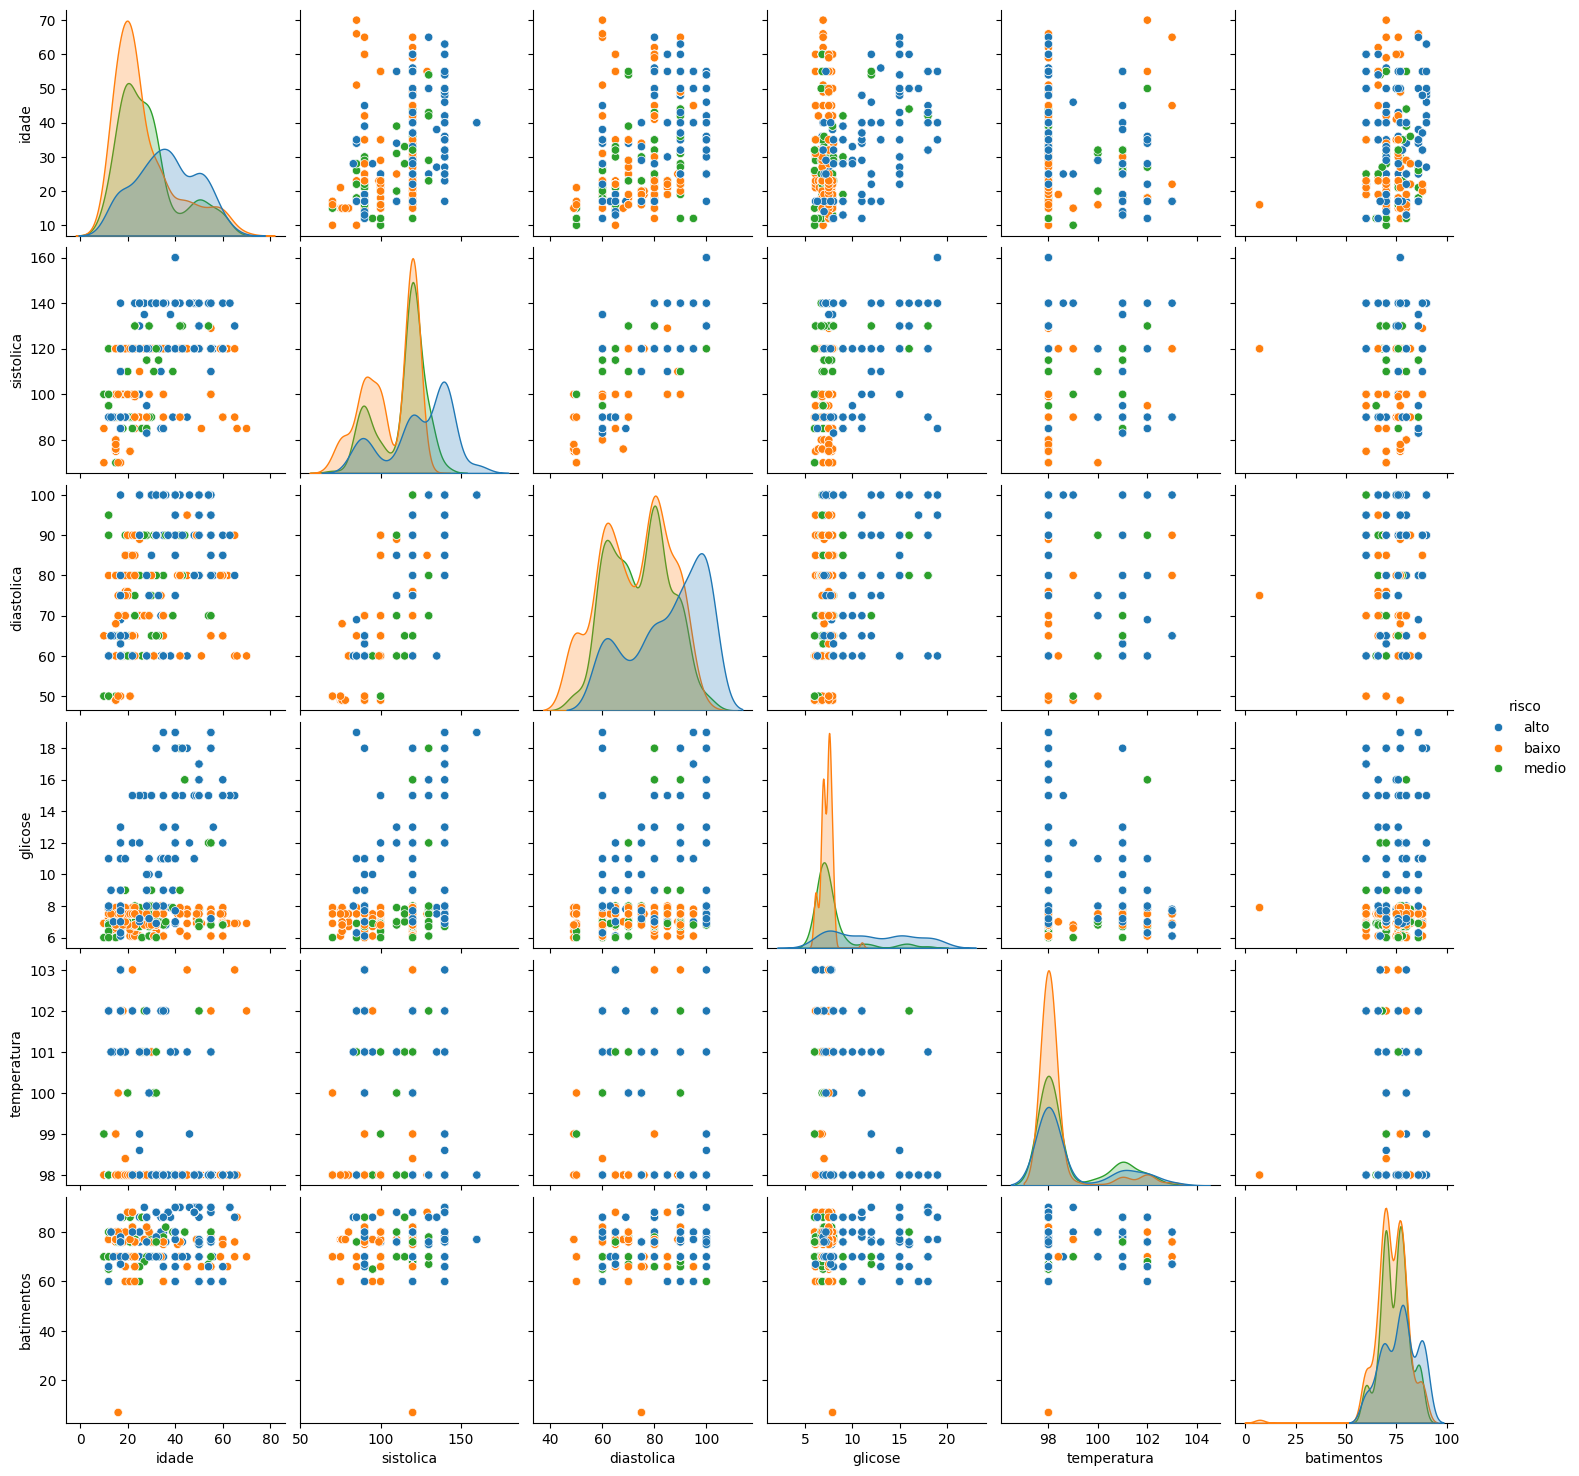

In [28]:
# com esse gráfico conseguimos ver a relação coluna por coluna (ele demora um pouco para carregar)
sns.pairplot(data=df, hue='risco');

Repare no padrão em forma de quadrado que os dados fazem, o que indica que um modelo de árvore (que traça um padrão similar) poderia ser um bom ajuste.

## Calculando e visualizando correlações entre os dados

In [29]:
# iremos investigar as correlaçoes, Há diversos tipos de correlação, dependendo da distribuição dos dados, algumas se encaixam melhor para o cálculo.
# removemos as categorias que queremos prever com drop, df_feat é de features ou características
df_feat = df.drop('risco', axis=1)
correlacao_p = df_feat.corr() # correlação de Pearson

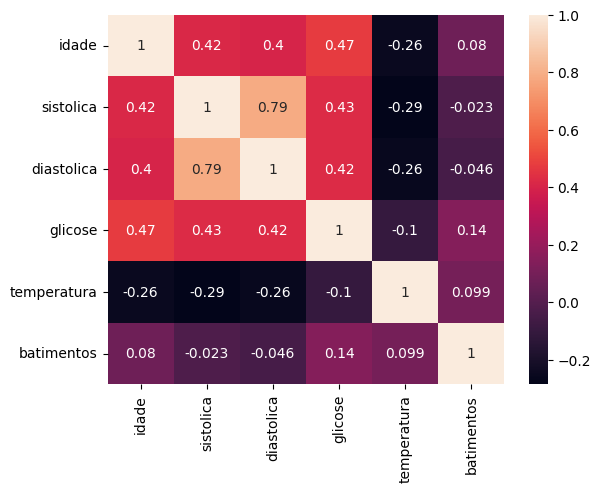

In [30]:
sns.heatmap(correlacao_p, annot=True);

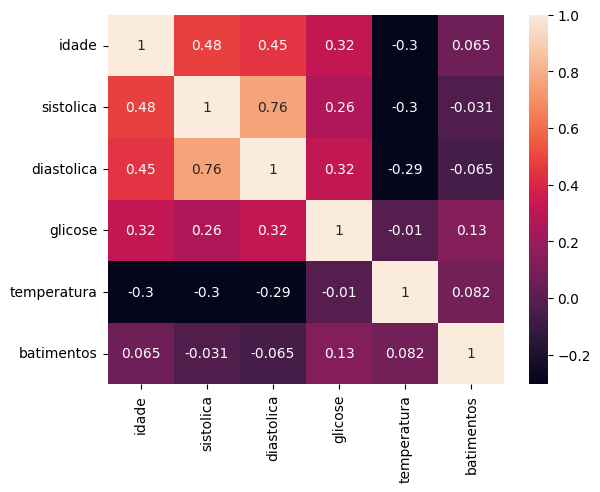

In [31]:
correlacao_s = df_feat.corr(method='spearman') # correlação de Spearman
sns.heatmap(correlacao_s, annot=True);